# 02 - Seasonality Feature Engineering

This notebook creates comprehensive seasonality features for the Airbnb dynamic pricing model, including Italian holidays, Fourier terms, and temporal patterns.

## Configuration


In [1]:
# Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import holidays
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Project paths
PROJECT_ROOT = Path.cwd().parent
FEATURES_DIR = PROJECT_ROOT / "features"
RESULTS_DIR = PROJECT_ROOT / "results"

# Create directories if they don't exist
for dir_path in [FEATURES_DIR, RESULTS_DIR]:
    dir_path.mkdir(exist_ok=True)

print(f"Features directory: {FEATURES_DIR}")
print(f"Results directory: {RESULTS_DIR}")


Features directory: /Users/antoniolavenia/Desktop/Data Science/features
Results directory: /Users/antoniolavenia/Desktop/Data Science/results


## Load Cleaned Data


In [2]:
# Load cleaned data
print("Loading cleaned data...")

listings_clean = pd.read_parquet(FEATURES_DIR / 'listings_clean.parquet')
calendar_clean = pd.read_parquet(FEATURES_DIR / 'calendar_clean.parquet')

print(f"✅ Loaded data:")
print(f"  Listings: {listings_clean.shape}")
print(f"  Calendar: {calendar_clean.shape}")
print(f"  Date range: {calendar_clean['date'].min()} to {calendar_clean['date'].max()}")


Loading cleaned data...
✅ Loaded data:
  Listings: (51338, 16)
  Calendar: (1827000, 9)
  Date range: 2020-01-01 00:00:00 to 2024-12-31 00:00:00


## Seasonality Feature Engineering


In [3]:
def create_seasonality_features(df):
    """
    Create comprehensive seasonality features for the calendar data.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Calendar dataframe with 'date' column
        
    Returns:
    --------
    pd.DataFrame
        Dataframe with added seasonality features
    """
    df = df.copy()
    
    print("Creating seasonality features...")
    
    # Basic temporal features
    df['day_of_week'] = df['date'].dt.dayofweek  # 0=Monday, 6=Sunday
    df['is_weekend'] = df['day_of_week'].isin([4, 5, 6])  # Friday, Saturday, Sunday
    df['month'] = df['date'].dt.month
    df['week_of_year'] = df['date'].dt.isocalendar().week
    df['day_of_year'] = df['date'].dt.dayofyear
    df['year'] = df['date'].dt.year
    
    # Italian holidays
    print("  Adding Italian holidays...")
    italy_holidays = holidays.Italy(years=range(2020, 2025))
    df['is_holiday'] = df['date'].apply(lambda x: x in italy_holidays)
    
    # Distance to holidays (days before/after)
    df['days_to_holiday'] = 0
    df['days_from_holiday'] = 0
    
    for idx, row in df.iterrows():
        date = row['date']
        # Convert to date if it's a datetime
        if hasattr(date, 'date'):
            date = date.date()
        
        # Find nearest holiday
        holiday_dates = [d for d in italy_holidays.keys() if d.year == date.year]
        if holiday_dates:
            distances = [(d - date).days for d in holiday_dates]
            min_distance = min(abs(d) for d in distances)
            if min_distance <= 7:  # Within a week
                df.loc[idx, 'days_to_holiday'] = min_distance
                df.loc[idx, 'days_from_holiday'] = min_distance
    
    # Holiday windows
    df['is_holiday_window'] = (df['days_to_holiday'] <= 1) | (df['days_from_holiday'] <= 1)
    
    # Fourier terms for annual seasonality
    print("  Adding Fourier terms...")
    t = df['day_of_year']
    
    # K=1 harmonic (annual cycle)
    df['fourier_sin_1'] = np.sin(2 * np.pi * t / 365.25)
    df['fourier_cos_1'] = np.cos(2 * np.pi * t / 365.25)
    
    # K=2 harmonic (semi-annual cycle)
    df['fourier_sin_2'] = np.sin(4 * np.pi * t / 365.25)
    df['fourier_cos_2'] = np.cos(4 * np.pi * t / 365.25)
    
    # Seasonal indicators
    df['is_spring'] = df['month'].isin([3, 4, 5])
    df['is_summer'] = df['month'].isin([6, 7, 8])
    df['is_autumn'] = df['month'].isin([9, 10, 11])
    df['is_winter'] = df['month'].isin([12, 1, 2])
    
    # Peak season (summer months)
    df['is_peak_season'] = df['month'].isin([6, 7, 8, 9])
    
    # Special Italian periods
    df['is_ferragosto'] = (df['month'] == 8) & (df['day_of_year'].between(220, 240))  # Mid-August
    df['is_easter_period'] = False  # Would need proper Easter calculation
    
    print(f"  ✅ Created {len([col for col in df.columns if col not in ['listing_id', 'date', 'available', 'price', 'city', 'is_available', 'booked']])} seasonality features")
    
    return df


def inject_weather_features(df, city_coords=None):
    """
    Stub function for weather features. Can be extended later.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Dataframe to add weather features to
    city_coords : dict
        Dictionary mapping city names to coordinates
        
    Returns:
    --------
    pd.DataFrame
        Dataframe with weather feature stubs
    """
    df = df.copy()
    
    # Create weather feature stubs (NaN by default)
    df['temp_avg'] = np.nan
    df['precip_mm'] = np.nan
    df['humidity'] = np.nan
    df['wind_speed'] = np.nan
    
    print("  ⚠️  Weather features are stubbed (NaN). Implement weather API integration as needed.")
    
    return df


In [4]:
# Apply seasonality features
calendar_with_seasonality = create_seasonality_features(calendar_clean)

# Add weather features (stubbed)
calendar_with_seasonality = inject_weather_features(calendar_with_seasonality)

print(f"\n✅ Seasonality features created!")
print(f"  Shape: {calendar_with_seasonality.shape}")
print(f"  New features: {len(calendar_with_seasonality.columns) - len(calendar_clean.columns)}")


Creating seasonality features...
  Adding Italian holidays...
  Adding Fourier terms...
  ✅ Created 21 seasonality features
  ⚠️  Weather features are stubbed (NaN). Implement weather API integration as needed.

✅ Seasonality features created!
  Shape: (1827000, 32)
  New features: 23


## Merge with Listings Features


In [ ]:
# Merge calendar with listings features
print("Merging calendar with listings features...")

# Select relevant listing features
listing_features = [
    'id', 'host_id', 'latitude', 'longitude', 'neighbourhood', 'neighbourhood_cleansed',
    'room_type', 'accommodates', 'bedrooms', 'bathrooms', 'amenities_count',
    'number_of_reviews', 'review_scores_rating', 'minimum_nights',
    'maximum_nights', 'availability_365', 'city'
]

# Filter to available columns
available_listing_features = [col for col in listing_features if col in listings_clean.columns]
print(f"Available listing features: {available_listing_features}")

# Merge
training_table = calendar_with_seasonality.merge(
    listings_clean[available_listing_features],
    left_on='listing_id',
    right_on='id',
    how='left'
)

# Drop duplicate id column
if 'id' in training_table.columns:
    training_table = training_table.drop('id', axis=1)

print(f"✅ Merged data shape: {training_table.shape}")
print(f"  Calendar entries: {len(calendar_with_seasonality)}")
print(f"  After merge: {len(training_table)}")
print(f"  Merge success rate: {len(training_table) / len(calendar_with_seasonality):.2%}")

# Check for missing values
missing_counts = training_table.isnull().sum()
if missing_counts.sum() > 0:
    print(f"\n⚠️  Missing values found:")
    print(missing_counts[missing_counts > 0])
else:
    print(f"\n✅ No missing values in merged data")


Merging calendar with listings features...
Available listing features: ['id', 'host_id', 'neighbourhood', 'neighbourhood_cleansed', 'room_type', 'accommodates', 'bedrooms', 'bathrooms', 'amenities_count', 'number_of_reviews', 'review_scores_rating', 'minimum_nights', 'maximum_nights', 'availability_365']
✅ Merged data shape: (1827000, 45)
  Calendar entries: 1827000
  After merge: 1827000
  Merge success rate: 100.00%

⚠️  Missing values found:
temp_avg         1827000
precip_mm        1827000
humidity         1827000
wind_speed       1827000
neighbourhood     657720
dtype: int64


In [6]:
## Add Migration Ratio Feature


In [7]:
# Load migration data from Excel
print("Loading migration data from Excel...")

# Read the Excel file with proper header
migration_df = pd.read_excel(PROJECT_ROOT / 'data' / 'movimento_comuni-2024.xlsx', skiprows=3)

# Clean the data - remove rows with NaN in key columns
migration_clean = migration_df.dropna(subset=['Provincia / Province', 'Comune / Municipality', 'Unnamed: 27'])

# Rename columns for clarity
migration_clean = migration_clean.rename(columns={
    'Provincia / Province': 'provincia',
    'Comune / Municipality': 'comune', 
    'Unnamed: 27': 'migration_ratio'
})

# Keep only relevant columns
migration_clean = migration_clean[['provincia', 'comune', 'migration_ratio']].copy()

print(f"✅ Migration data loaded: {migration_clean.shape}")
print(f"  Provinces: {migration_clean['provincia'].nunique()}")
print(f"  Comuni: {migration_clean['comune'].nunique()}")
print(f"  Migration ratio range: {migration_clean['migration_ratio'].min():.4f} - {migration_clean['migration_ratio'].max():.4f}")

# Show sample data
print(f"\n📊 Sample migration data:")
print(migration_clean.head(10))


Loading migration data from Excel...
✅ Migration data loaded: (238, 3)
  Provinces: 9
  Comuni: 238
  Migration ratio range: 0.0000 - 0.3762

📊 Sample migration data:
   provincia                   comune  migration_ratio
2    TRAPANI                   Alcamo         0.011244
3    TRAPANI         Buseto Palizzolo         0.000848
4    TRAPANI       Calatafimi-Segesta         0.001610
5    TRAPANI     Campobello di Mazara         0.000129
6    TRAPANI  Castellammare del Golfo         0.059549
7    TRAPANI            Castelvetrano         0.030180
8    TRAPANI                Custonaci         0.003239
9    TRAPANI                    Erice         0.020361
10   TRAPANI                Favignana         0.017254
11   TRAPANI                Gibellina         0.000252


In [8]:
# Merge migration data with training table
print("Merging migration data with training table...")

# First, we need to match the comune names
# The listings data has 'neighbourhood_cleansed' which should match with 'comune' in migration data
print(f"Unique neighbourhoods in listings: {listings_clean['neighbourhood_cleansed'].nunique()}")
print(f"Sample neighbourhoods: {listings_clean['neighbourhood_cleansed'].dropna().head(10).tolist()}")

# Create a mapping from comune to migration_ratio
migration_dict = dict(zip(migration_clean['comune'], migration_clean['migration_ratio']))

# Add migration_ratio to training_table
training_table['migration_ratio'] = training_table['neighbourhood_cleansed'].map(migration_dict)

# Check merge success
merge_success = training_table['migration_ratio'].notna().sum()
total_rows = len(training_table)
print(f"✅ Migration ratio added to {merge_success:,} rows ({merge_success/total_rows:.1%})")

# Show statistics
print(f"\n📊 Migration ratio statistics:")
print(f"  Mean: {training_table['migration_ratio'].mean():.4f}")
print(f"  Median: {training_table['migration_ratio'].median():.4f}")
print(f"  Min: {training_table['migration_ratio'].min():.4f}")
print(f"  Max: {training_table['migration_ratio'].max():.4f}")

# Show correlation with price
migration_price_corr = training_table['migration_ratio'].corr(training_table['price'])
print(f"  Correlation with price: {migration_price_corr:.4f}")


Merging migration data with training table...
Unique neighbourhoods in listings: 367
Sample neighbourhoods: ['Marsala', 'Agrigento', 'Piedimonte Etneo', 'Erice', 'San Vito Lo Capo', 'Siracusa', 'Avola', 'Modica', 'Acireale', 'Isola delle Femmine']
✅ Migration ratio added to 1,755,747 rows (96.1%)

📊 Migration ratio statistics:
  Mean: 0.1174
  Median: 0.0520
  Min: 0.0000
  Max: 0.3762
  Correlation with price: -0.0283


## Feature Analysis and Visualization


Analyzing seasonality patterns...


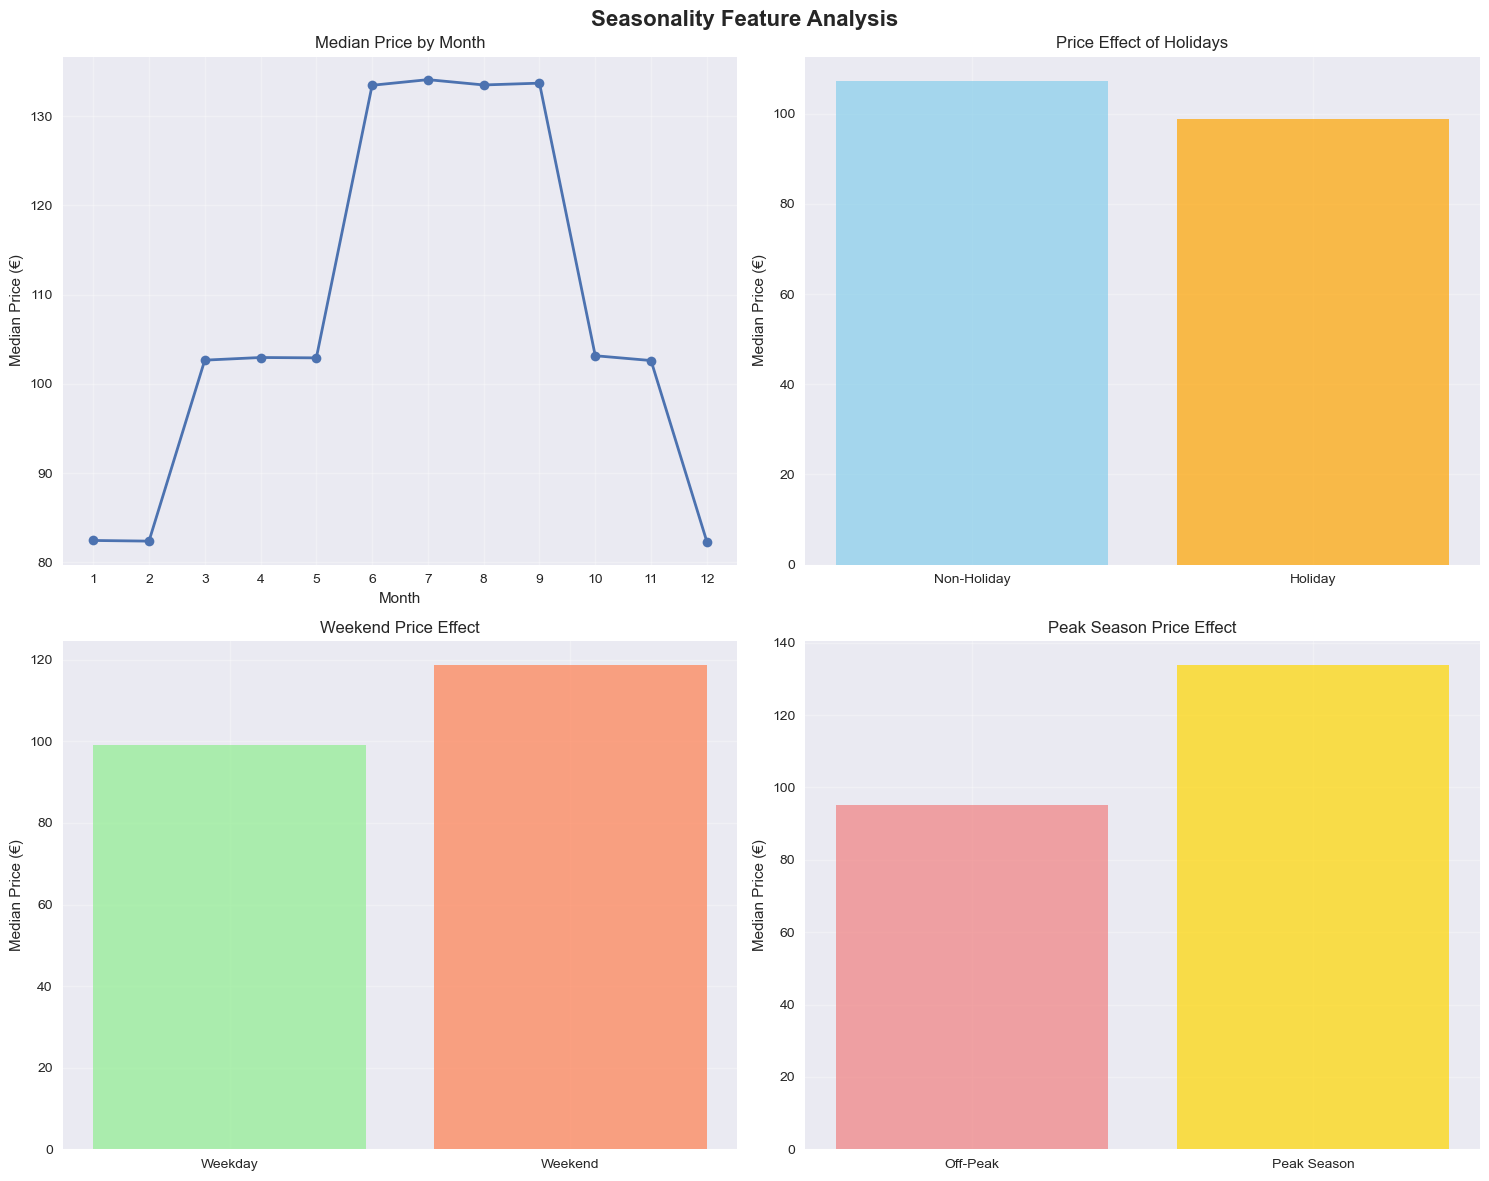


Feature correlation with price:
price                1.000000
bathrooms            0.446320
bedrooms             0.441978
accommodates         0.413685
amenities_count      0.187100
fourier_cos_1        0.151279
minimum_nights       0.094279
number_of_reviews    0.083086
day_of_week          0.076466
fourier_sin_1        0.068806
dtype: float64


In [9]:
# Analyze seasonality patterns
print("Analyzing seasonality patterns...")

# Set up plotting
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Seasonality Feature Analysis', fontsize=16, fontweight='bold')

# 1. Price by month with holidays
monthly_price = training_table.groupby('month')['price'].median()
axes[0, 0].plot(monthly_price.index, monthly_price.values, marker='o', linewidth=2)
axes[0, 0].set_title('Median Price by Month')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Median Price (€)')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].grid(True, alpha=0.3)

# 2. Holiday effect on prices
holiday_prices = training_table.groupby('is_holiday')['price'].median()
axes[0, 1].bar(['Non-Holiday', 'Holiday'], holiday_prices.values, alpha=0.7, color=['skyblue', 'orange'])
axes[0, 1].set_title('Price Effect of Holidays')
axes[0, 1].set_ylabel('Median Price (€)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Weekend effect
weekend_prices = training_table.groupby('is_weekend')['price'].median()
axes[1, 0].bar(['Weekday', 'Weekend'], weekend_prices.values, alpha=0.7, color=['lightgreen', 'coral'])
axes[1, 0].set_title('Weekend Price Effect')
axes[1, 0].set_ylabel('Median Price (€)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Peak season effect
peak_prices = training_table.groupby('is_peak_season')['price'].median()
axes[1, 1].bar(['Off-Peak', 'Peak Season'], peak_prices.values, alpha=0.7, color=['lightcoral', 'gold'])
axes[1, 1].set_title('Peak Season Price Effect')
axes[1, 1].set_ylabel('Median Price (€)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'seasonality_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature correlation with price
print("\nFeature correlation with price:")
numeric_features = training_table.select_dtypes(include=[np.number]).columns
price_correlations = training_table[numeric_features].corrwith(training_table['price']).abs().sort_values(ascending=False)
print(price_correlations.head(10))


## Save Training Table


In [10]:
# Save the final training table
print("Saving training table...")

# Ensure no future leakage - all features should be available at prediction time
print("Validating no future leakage...")
assert training_table['date'].max() <= pd.Timestamp.now(), "Data contains future dates"

# Save training table
training_table.to_parquet(FEATURES_DIR / 'training_table.parquet', index=False)
print(f"✅ Saved training_table.parquet: {training_table.shape}")

# Summary statistics
print(f"\n📊 Training Table Summary:")
print(f"  Shape: {training_table.shape}")
print(f"  Date range: {training_table['date'].min()} to {training_table['date'].max()}")
print(f"  Features: {len(training_table.columns)}")
print(f"  Missing values: {training_table.isnull().sum().sum()}")

# Feature categories
seasonality_features = [col for col in training_table.columns if any(x in col for x in ['fourier', 'is_', 'day_of', 'month', 'week', 'year', 'holiday', 'season'])]
listing_features = [col for col in training_table.columns if col in ['accommodates', 'bedrooms', 'bathrooms', 'review_scores_rating', 'amenities_count']]
weather_features = [col for col in training_table.columns if col in ['temp_avg', 'precip_mm', 'humidity', 'wind_speed']]

print(f"\n📈 Feature Categories:")
print(f"  Seasonality features: {len(seasonality_features)}")
print(f"  Listing features: {len(listing_features)}")
print(f"  Weather features: {len(weather_features)} (stubbed)")

print(f"\n✅ Feature engineering completed!")
print(f"📁 Training table saved to: {FEATURES_DIR / 'training_table.parquet'}")
print(f"📊 Analysis plots saved to: {RESULTS_DIR}")


Saving training table...
Validating no future leakage...
✅ Saved training_table.parquet: (1827000, 46)

📊 Training Table Summary:
  Shape: (1827000, 46)
  Date range: 2020-01-01 00:00:00 to 2024-12-31 00:00:00
  Features: 46
  Missing values: 8036973

📈 Feature Categories:
  Seasonality features: 22
  Listing features: 5
  Weather features: 4 (stubbed)

✅ Feature engineering completed!
📁 Training table saved to: /Users/antoniolavenia/Desktop/Data Science/features/training_table.parquet
📊 Analysis plots saved to: /Users/antoniolavenia/Desktop/Data Science/results
